# Risk Score Regression with XGBoost

This notebook trains an XGBoost regression model to predict `risk_score` from the textile wastewater dataset.


In [1]:
%pip install -q xgboost scikit-learn pandas numpy joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor

RANDOM_STATE = 42
DATA_PATH = Path("textile_wastewater_dataset.csv")
MODEL_PATH = Path("risk_score_xgboost_pipeline.pkl")

In [3]:
df = pd.read_csv(DATA_PATH)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
display(df.head())
display(df.dtypes)

Rows: 4000, Columns: 12


,shift_batch_id,production_volume_kg,chemical_usage_liters,etp_status,electricity_usage_kwh,Unnamed: 5,etp_cost_bdt,etp_capacity_liters,ph,bod_mg_per_l,cod_mg_per_l,risk_score
0,B38893,5925.9,43834.4,1,18874.1,NaN,1140.2,59292,7.52,125.2,294.5,16.77
1,B26361,3860.2,37205.1,1,8589.2,NaN,1668.2,70729,7.08,143.4,393.6,13.43
2,B56566,2851.5,28170.1,0,7923.9,NaN,3.7,53747,10.30,582.0,1509.0,88.20
3,B14207,3573.8,27312.6,1,10535.1,NaN,953.6,61563,8.97,87.5,258.9,16.78
4,B62350,3219.0,26493.3,0,9031.9,NaN,70.8,65784,11.75,805.9,1988.9,100.00


shift_batch_id            object
production_volume_kg     float64
chemical_usage_liters    float64
etp_status                 int64
electricity_usage_kwh    float64
Unnamed: 5               float64
etp_cost_bdt             float64
etp_capacity_liters        int64
ph                       float64
bod_mg_per_l             float64
cod_mg_per_l             float64
risk_score               float64
dtype: object

In [4]:
target_col = "risk_score"
if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found in dataset.")

X = df.drop(columns=[target_col]).copy()
y = pd.to_numeric(df[target_col], errors="coerce")


valid_target = y.notna()
if not valid_target.all():
    dropped_rows = int((~valid_target).sum())
    print(f"Dropping {dropped_rows} rows with invalid target values.")
    X = X.loc[valid_target].copy()
    y = y.loc[valid_target].copy()

id_like_cols = []
for col in X.columns:
    if X[col].dtype == "object":
        unique_ratio = X[col].nunique(dropna=False) / max(len(X), 1)
        if ("id" in col.lower() or "batch" in col.lower()) and unique_ratio > 0.8:
            id_like_cols.append(col)

all_missing_cols = [col for col in X.columns if X[col].isna().all()]
constant_cols = [col for col in X.columns if X[col].nunique(dropna=True) <= 1]

cols_to_drop = sorted(set(id_like_cols + all_missing_cols + constant_cols))
if cols_to_drop:
    print("Dropping non-informative columns:", cols_to_drop)
    X = X.drop(columns=cols_to_drop)

categorical_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()

if len(categorical_cols) + len(numeric_cols) == 0:
    raise ValueError("No usable feature columns left after preprocessing.")

print("Using features:", X.columns.tolist())
print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)
print(f"Prepared rows: {len(X)}")

Dropping non-informative columns: ['Unnamed: 5', 'shift_batch_id']
Using features: ['production_volume_kg', 'chemical_usage_liters', 'etp_status', 'electricity_usage_kwh', 'etp_cost_bdt', 'etp_capacity_liters', 'ph', 'bod_mg_per_l', 'cod_mg_per_l']
Numeric columns: ['production_volume_kg', 'chemical_usage_liters', 'etp_status', 'electricity_usage_kwh', 'etp_cost_bdt', 'etp_capacity_liters', 'ph', 'bod_mg_per_l', 'cod_mg_per_l']
Categorical columns: []
Prepared rows: 4000


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ],
    remainder="drop",
)

model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.0,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ]
)

In [6]:
pipeline.fit(X_train, y_train)
preds = pipeline.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

MAE:  2.6188
RMSE: 3.3101
R2:   0.9906


In [7]:
joblib.dump(pipeline, MODEL_PATH)
print(f"Saved model pipeline to: {MODEL_PATH.resolve()}")

Saved model pipeline to: E:\Hackathons\EcoWeave_Frontend\EcoWeave\risk_score_xgboost_pipeline.pkl


In [8]:
loaded_pipeline = joblib.load(MODEL_PATH)
sample_predictions = loaded_pipeline.predict(X_test.head(5))

pd.DataFrame(
    {
        "actual": y_test.head(5).values,
        "predicted": sample_predictions,
    }
)

,actual,predicted
0,17.20,13.253918
1,20.81,21.221392
2,14.45,12.216259
3,14.67,15.374547
4,15.00,15.037363


In [9]:
train_preds = pipeline.predict(X_train)
print("Train R²:", r2_score(y_train, train_preds))
print("Test  R²:", r2_score(y_test, preds))

Train R²: 0.9992887992169794
Test  R²: 0.9905924835886245


In [10]:
eval_df = pd.DataFrame({"actual": y_test.values, "predicted": preds})
eval_df["abs_error"] = (eval_df["actual"] - eval_df["predicted"]).abs()

print("Prediction summary:")
display(eval_df[["predicted"]].describe().T)

print("Top 10 largest absolute errors:")
display(eval_df.sort_values("abs_error", ascending=False).head(10))

Prediction summary:


,count,mean,std,min,25%,50%,75%,max
predicted,800.0,33.256981,33.748844,3.238765,12.545326,16.305959,24.716003,100.648148


Top 10 largest absolute errors:


,actual,predicted,abs_error
143,23.74,13.408039,10.331961
457,80.37,89.686310,9.316310
392,30.21,20.984806,9.225194
232,17.56,8.346876,9.213124
637,91.95,82.741920,9.208080
10,2.44,11.627629,9.187629
58,75.25,84.276855,9.026855
519,91.73,82.732857,8.997143
782,93.07,84.323685,8.746315
572,6.97,15.631950,8.661950


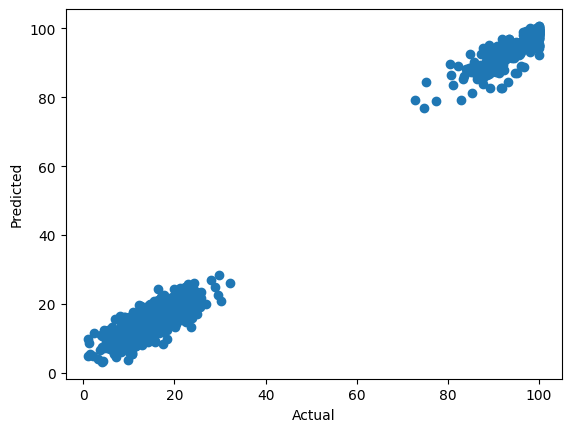

In [13]:
import matplotlib.pyplot as plt
plt.scatter(y_test, preds)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()